In [1]:
!pip install scipy numpy ipywidgets matplotlib scikit-learn
import numpy as np
from scipy.fftpack import fft, rfft
from scipy.io import wavfile
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from ipywidgets import HBox, VBox, interactive, Layout, Checkbox, fixed
import random
from odrpack import odr_fit


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


von: Raphael Schütz - raphael.schuetz0311@gmail.com


# Ein Algorithmus zum Stimmen einer Floyd-Rose-Gitarre
## Begriffe
<img style="height:30rem;" src="assets/gitarren_begriffe.png"></img>
<figcaption>Fig. 1 - Bezeichnungen der wichtigsten Bauteile einer E-Gitarre.</figcaption>

## Einleitung
Es gibt ein Problem beim Stimmen von Floyd-Rose-Gitarren. Bei diesen Gitarren wird eine Saite zwischen dem Gitarrenkopf und einer bis zu einem gewissen Grad rotierbaren Brücke gespannt. An der Brücke halten unterhalb des Drehpunkts Federn dagegen, wenn man Saiten einspannt. Das Floyd-Rose-Tremolo hat einen Hebel, den man ziehen oder drücken kann. Beim Musizieren ändert das den Ton.

### Bilder des Floyd Rose Tremolos

<img src="assets/tremolo_spec.jpeg" style="height:25rem;" />

<figcaption>Fig. 2 - Aufbau eines Floyd-Rose Tremolos</figcaption>


<img style="height:30rem;" src="assets/floydrose_back.jpg"></img>
<figcaption>Fig. 3 - Hier sieht man die Federn, die eine Gegenkraft zu den gespannten Saiten leisten.</figcaption>

#### Neutrale Lage
Die folgende Abbildung zeigt die Gitarre in einer neutralen Position:
<div style="display:flex; align-items: flex-end;">
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_frontside_neutral.jpg"></img>
        <figcaption>Fig. 4 - Vorderseite der Gitarre bei neutraler Position.</figcaption>
    </div>
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_backside_neutral.jpg"></img>
        <figcaption>Fig. 5 - Rückseite der Gitarre bei neutraler Position.</figcaption>
    </div>
</div>

#### Saiten gespannter
Wenn der Musiker den Ton der Saiten erhöhen möchte, kann er den Tremolo-Hebel anziehen, sodass die Saiten unter einer erhöhten Spannung stehen.  
<div style="display:flex; align-items: flex-end;">
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_frontside_strings_stressed.jpg"></img>
        <figcaption>Fig. 6 - Vorderseite der Gitarre bei gespannten Saiten.</figcaption>
    </div>
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_backside_strings_stressed.jpg"></img>
        <figcaption>Fig. 7 - Rückseite der Gitarre bei gespannten Saiten.</figcaption>
    </div>
</div>

#### Saiten entspannter
Wenn der Musiker den Ton der Saiten verringern möchte, kann er den Tremolo-Hebel zur Gitarre drücken, sodass die Saiten unter einer niedrigeren Spannung stehen.
<div style="display:flex; align-items: flex-end;">
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_frontside_strings_released.jpg"></img>
        <figcaption>Fig. 8 - Vorderseite der Gitarre bei entspannten Saiten.</figcaption>
    </div>
    <div style="padding:10px;">
        <img style="width:35rem;" src="assets/floydrose_backside_strings_released.jpg"></img>
        <figcaption>Fig. 9 - Rückseite der Gitarre bei entspannten Saiten.</figcaption>
    </div>
</div>

## Problem

Auch wenn diese Architektur einzigartige Klangwelten ermöglicht, erschwert sie das Stimmen der Gitarre erheblich. Beim Stimmen erhöht oder verringert man die Spannung einer Saite, indem man deren Länge verändert. Demnach erhöht oder verringert sich die Auslenkung der Federn, da zum Beispiel bei geringerer Spannung der Saiten auch eine geringere Kraft auf die Federn wirkt. Das Resultat davon ist, dass sich der Winkel des Floyd-Rose-Tremolos verändert. Das führt dazu, dass die anderen Saiten verstimmt werden, wenn man eine Saite stimmt.

## Ziel

In dieser Arbeit soll ein Weg gefunden werden, alle Saiten in die richtige Stimmung zu bringen, wobei jede Saite nur einmal gestimmt werden muss.

## Methodik

Zunächst analysieren wir die Bauteile der Gitarre und bestimmen ihre Eigenschaften. Danach wird ein mathematisches Modell aufgestellt, das das Verhalten der Saiten beschreibt. Anschließend wird dieses Modell durch ein Experiment überprüft. Die gewonnenen Erkenntnisse werden dann genutzt, um das Ziel in ein mathematisches Problem zu überführen. Abschließend wird die mathematische Lösung in Form eines Programms umgesetzt.

## Analyse

Zunächst analysieren wir den physikalischen Aufbau der Gitarre und vereinfachen ihn, um daraus ein mathematisches Modell abzuleiten. Die Brücke der Gitarre kann bei einem Floyd-Rose-Tremolo bis zu einem gewissen Grad rotieren. Ein entsprechendes vereinfachtes Modell ist in der folgenden Abbildung dargestellt.

<img src="assets/floyd_rose_paint.png" style="height:20rem;"/>
<figcaption>Fig. 10 - Physikalisches Modell für eine Saite an einem Floyd-Rose-Tremolo. Blaue Objekte sind beweglich. Braune Objekte sind unbeweglich.</figcaption>

### Elastizität der Saiten
Stahlsaiten sind bis zu einem gewissen Grad elastisch und können sich unter Zugkraft dehnen. Dieses Materialverhalten wird durch den Young’schen Modul beschrieben [1]. Solange sich die Saite im linear-elastischen Bereich des Materials befindet, gilt zusätzlich das Hooke’sche Gesetz [2]. Aufgrund des hohen Young-Moduls besitzen Stahlsaiten jedoch eine sehr große effektive Federkonstante, sodass die elastische Längenänderung unter normalen Betriebsbedingungen vergleichsweise gering ist.

#### Experiment: Sind Stahlsaiten elastisch?

In diesem Experiment wird untersucht, ob Stahlsaiten elastische Eigenschaften besitzen, vergleichbar mit einem sehr steifen Gummiband. Die zentrale Fragestellung lautet:

**Dehnt sich eine Stahlsaite messbar, wenn ihre Spannung erhöht wird?**

Diese Frage ist besonders relevant für Saiteninstrumente wie Gitarren. Bei herkömmlichen Gitarren ohne Floyd-Rose-System darf sich der Abstand zwischen Sattel und Brücke beim Stimmen nicht verändern, da sonst die Position der Bünde nicht mehr korrekt wäre. In diesem Fall wären gegriffene Akkorde nicht mehr sauber gestimmt, außerdem würden sich die übrigen Saiten gegenseitig beeinflussen.

Beim Stimmen wird die Saite jedoch um den Wirbel gewickelt, wodurch sich ihre Zugspannung erhöht. Damit die feste Mensur erhalten bleibt, muss sich die Saite insgesamt verlängern und gleichzeitig minimal dünner werden. Dies entspricht dem Verhalten eines elastischen Körpers unter Zugspannung.


##### Materialien

- 1× Gitarre mit starrer Brücke (keine Floyd-Rose-Brücke, z. B. Yamaha Pacifica)
- 1× Gitarre mit Floyd-Rose-Brücke (rotierbare Brücke)
- Tesafilm (für Markierungen auf den Saiten)


##### Durchführung

Zunächst wurde die hohe E-Saite etwas tiefer gestimmt, sodass sie ungefähr die Frequenz der darunterliegenden H-Saite hatte. Dabei wurde darauf geachtet, dass die Saite weiterhin eine angemessene Grundspannung aufwies.

Anschließend wurden kleine Tesafilm-Schnipsel auf die hohe E-Saite geklebt. Die Schnipsel wurden so positioniert, dass ihre Kante exakt mittig über einem Bund lag. Insgesamt wurden sechs Schnipsel in unterschiedlichen Abständen zwischen Sattel und Brücke angebracht.

Zusätzlich wurde auf den übrigen Saiten jeweils ein Kontroll-Schnipsel auf denselben Bünden angebracht. Diese dienten als Referenz, um eventuelle Verschiebungen durch das Stimmen besser beurteilen zu können. Die Bundstäbchen fungierten dabei als feste Referenzpositionen.

Im nächsten Schritt wurde die Spannung der hohen E-Saite erhöht, bis der dem Sattel nächstgelegene Schnipsel einen deutlich sichtbaren Abstand zum darunterliegenden Bund aufwies. Anschließend wurde überprüft, wie stark sich die übrigen Schnipsel im Vergleich zu ihren jeweiligen Referenzbünden verschoben hatten.


##### Beobachtung

Die Tesafilm-Schnipsel, die sich näher am Sattel befanden, legten eine deutlich größere Strecke zurück als jene in der Nähe der Brücke. Die Verschiebung nahm kontinuierlich von der Kopfplatte in Richtung Brücke ab.

Die Kontroll-Schnipsel auf den übrigen Saiten zeigten hingegen keine oder nur eine kaum sichtbare Verschiebung. Dies deutet darauf hin, dass die beobachtete Bewegung nicht durch ein Verschieben des Instruments oder der Biegung des Halses verursacht wurde, sondern durch eine tatsächliche Längenänderung der gespannten Saite.

<div style="display:flex; gap:1.5rem; align-items:flex-start;">

<!-- Pacifica -->
<div style="flex:1;">
  <h5>Pacifica (starre Brücke)</h5>
  <table style="font-size:0.85rem;">
    <tr>
      <th style="border:1px solid #ccc; padding:0.3rem;">Bund</th>
      <th style="border:1px solid #ccc; padding:0.3rem;">Ruhezustand</th>
      <th style="border:1px solid #ccc; padding:0.3rem;">Erhöhte Spannung</th>
    </tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">1</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_1.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 1 (inkl. Referenzsaiten)</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_1t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 1 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">2</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_2.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 2 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_2t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 2 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">4</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_4.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 4 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_4t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 4 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">6</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_6.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 6 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_6t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 6 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">8</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_8.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 8 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_8t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 8 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">12</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_12.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 12 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_12t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 12 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">16</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_16.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 16 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_16t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 16 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">22</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_22.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 22 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/p_22t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 22 – Spannung</figcaption></figure></td></tr>
  </table>
</div>

<!-- Floyd Rose -->
<div style="flex:1;">
  <h5>Floyd-Rose-Gitarre</h5>
  <table style="border-collapse:collapse; font-size:0.85rem;">
    <tr>
      <th style="border:1px solid #ccc; padding:0.3rem;">Bund</th>
      <th style="border:1px solid #ccc; padding:0.3rem;">Ruhezustand</th>
      <th style="border:1px solid #ccc; padding:0.3rem;">Erhöhte Spannung</th>
    </tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">1</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_1.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 1 (inkl. Referenzsaiten)</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_1t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 1 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">2</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_2.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 2 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_2t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 2 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">4</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_4.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 4 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_4t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 4 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">6</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_6.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 6 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_6t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 6 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">8</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_8.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 8 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_8t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 8 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">12</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_12.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 12 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_12t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 12 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">16</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_16.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 16 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_16t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 16 – Spannung</figcaption></figure></td></tr>
    <tr><td style="border:1px solid #ccc; padding:0.3rem;">22</td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_22.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 22 – Ruhe</figcaption></figure></td>
      <td style="border:1px solid #ccc; padding:0.3rem;"><figure style="margin:0;"><img src="assets/fr_22t.jpeg" style="width:8.5rem;"><figcaption style="font-size:0.7rem;">Bund 22 – Spannung</figcaption></figure></td></tr>
  </table>
</div>

</div>

#### Fazit

Die Beobachtungen zeigen, dass **Gitarrensaiten elastisch, aber sehr starr** sind.  
Beim Erhöhen der Spannung durch Aufwickeln am Wirbel bewegen sich die aufgeklebten Schnipsel entlang der Saite unterschiedlich:

- **Schnipsel nahe der Brücke (fixer Punkt)** verschieben sich nur sehr wenig.  
- **Schnipsel weiter entfernt von der Brücke** verschieben sich stärker.

**Aussage:**  
Die Saite dehnt sich wie eine **starke, elastische Feder**. Je näher ein Punkt an der fixierten Brücke ist, desto geringer ist seine Bewegung.  
Das bestätigt: **die Saite verteilt die Dehnung entlang ihrer Länge**, wobei der Fixpunkt nahezu unbewegt bleibt.


### Mathematisches Modell der Gitarrensaite

Wir können die Gitarrensaite als **Feder mit sehr hoher Federkonstante** betrachten.  
Die auf die Saite wirkende Kraft hängt ab von:

1. **Der Zugkraft am Stimmwirbel**, mit der die Saite auf Spannung gebracht wird.  
2. **Der physikalischen Auslenkung der Feder unterhalb des Tremolos** (bei Floyd-Rose-Systemen).  

Die erforderliche Kraft, um die Feder unterhalb des Tremolos auszudehnen, **ist nicht direkt gleich der Spannung der Saite**, da zusätzlich das **Drehmoment** berücksichtigt werden muss.

Für das Stimmen einer Saite interessiert uns vor allem: **Welche physikalischen Größen bestimmen die Schwingungsfrequenz?**  
Stimmen bedeutet, die Zugkraft so einzustellen, dass die Saite mit der gewünschten Eigenfrequenz schwingt.  

Der Zusammenhang zwischen **Saitenlänge \(L_S\)**, **Zugkraft \(F\)**, **linearer Massendichte \(\mu\)** und **Frequenz \(f\)** wird durch das Mersennesche Gesetz beschrieben [3]:

$$
f = \frac{1}{2 L_S} \sqrt{\frac{F}{\mu}}
$$


Da die exakten analytischen Ausdrücke für die Kräfte und Spannungen der Saite schnell sehr komplex und unübersichtlich werden, und im Rahmen der Anwendung nur vergleichsweise **kleine Änderungen der Brückenposition** erwartet werden, kann hier die vollständige Herleitung vernachlässigt werden.  
Für kleine Auslenkungen $\Delta x$ gilt aufgrund der **Taylor-Approximation** eine annähernd lineare Beziehung zwischen Zugkraft und Dehnung.  
Im Folgenden wird daher ein **Experiment vorgestellt**, das die angenommene Lineariät der Saite überprüft.


## Experiment

Um die Theorie zu überprüfen, wird ein Experiment durchgeführt, bei dem die Frequenzänderungen der Saiten gemessen werden, wenn eine andere Saite verstimmt wird.

Zunächst wird jede Saite in eine Ausgangsposition gebracht. Eine Standard-Gitarrenstimmung ist E–A–D–G–B–E. Da eine Gitarre aufgrund menschlicher Ungenauigkeiten nicht perfekt gestimmt werden kann, werden die Ausgangsfrequenzen der Saiten zunächst gemessen und aufgezeichnet.

Anschließend wird jeweils eine Saite um ein beliebiges $\Delta$ verstimmt. Dieses $\Delta$ wird so gewählt, dass die Verstimmung deutlich hörbar ist. Auch dieses $\Delta$ wird gemessen und dokumentiert.

Jede Saite wird in vier Schritten nach oben und vier Schritten nach unten verstimmt. Für jeden Schritt wird die Frequenz aller anderen Saiten gemessen und aufgezeichnet.

Das Ziel des Experiments ist es zu beobachten, ob das System
- hinreichend linear ist (was nach der Theorie nicht zu erwarten)
- elastisch ist.

Elastizität bedeutet hier, dass die Frequenz einer Saite wieder in ihren Ausgangszustand zurückkehrt, sobald die Saite selbst wieder in die Ausgangslage gebracht wird. Um dies zu überprüfen, werden nach allen Verstimmungsschritten die Endfrequenzen mit den Anfangswerten verglichen.

Zur Frequenzmessung wird ein Python-Programm eingesetzt, das mithilfe der Fourier-Transformation die Schwingungsfrequenzen bestimmt. Die Visualisierung erfolgt ebenfalls mit Python, wobei die Bibliothek matplotlib.pyplot für die Darstellung der Graphen genutzt wird.

Insgesamt werden 324 gelabelte Audio-Samples aufgenommen:

* Es gibt 6 Saiten,
* jede Saite beeinflusst alle 6 Saiten,
* jede Saite wird dabei in 4 Schritten nach oben und 4 Schritte nach unten verstimmt,
* hinzu kommt noch die Ausgangsposition.
Damit ergibt sich die Anzahl der Messungen zu
$$ 
324 = 6*6*(4*2+1).
$$

#### Frequenzmessung

Die Audio-Samples werden mit Hilfe der Fourier Transformation in den Frequenzbereich transformiert. Die Frequenz mit der höchsten Amplitude wird als die Frequenz der Saite angenommen.
Der Python Code um von einer Audio-Datei die Frequenz zu erhalten ist im Folgenden definiert: 

In [2]:
def get_samples(filepath):
    fs, data = wavfile.read(filepath)  # Load the data
    if len(data.shape) > 1:  # Stereo → Mono
        data = data.mean(axis=1)
    return data, fs

In [3]:
def fourier_transform(samples):
    spectrum = fft(samples)
    half = len(spectrum) // 2  # Take the first half of the spectrum
    return spectrum[:half]


In [4]:
def get_peak_frequency(spectrum, samplerate):
    # Betragsspektrum
    magnitude = np.abs(spectrum)
    # Peaks finden (optional: Mindestprominenz gegen Rauschen)
    peak_idx = np.argmax(magnitude)
    # Map the index to a frequency value
    frequency = peak_idx * (samplerate / (2 * len(spectrum)))
    return frequency

In [5]:
def get_frequency_from_file(filepath):
    samples, samplerate = get_samples(filepath)
    spectrum = fourier_transform(samples)
    return get_peak_frequency(spectrum, samplerate)

#### Frequenz zu Cent Konvertierer 
Für Musiker ist es üblich die Frequenzdifferenz in Cent zu messen. Zwischen 2 Ganztönen liegen immer 100 Cent. Cent sind Logarithmisch. Da es 12 Töne gibt, gibt es also 1200 Cent in einer Oktave.  Beispiel: Wenn man die Frequenz verdoppelt muss es also um eine Oktave (1200 Cent) verschoben sein. $1200 = a * log_2(400/200) = a* log_2(2) = a = 1200$


In [6]:
def frequency_difference_to_cent(f1, f2):
    return 1200 * np.log2(f1 / f2)  # 1200 Cent entsprechen einer Oktave

#### Visualisierung der Messdaten

Die Visualisierung zeigt die Frequenz der Saiten in Abhängigkeit von der Verstimmung. Zum Visualisieren wird Matplotlib und IPyWidgets verwendet.
Die Daten zum Visualisieren werden wie folgt strukturiert:

```
data = {
    'E2': {                              // The first key represents the String that is detuned
        'E2': [200Hz,220Hz,...,330Hz],                          // The second key represents the string on which the impact is measured
                                         // The Value is a List of the length 8. on Index 0 is the measurement where the detuned string was tuned the lowest.  
        'D3': [340Hz,330Hz,...,300Hz]),
        ...,
        'E4': [...])
    },
    ...
    'E4': {
        'E2': [...]),
        'A2': [...]),
        ...,
        'E4': [...])
    }
}
```
Die Namen der Saiten sind wie folgt definiert:
1. E2
2. A2
3. D3
4. G3
5. B3
6. E4

Das folgende Programm ermöglicht es uns die Daten zu visualisieren. Es gibt 6 Abbildungen mit jewails 6 Plots. Jede Abbildung zeigt wie sich alle Saiten verstimmen, wenn sich eine andere Saite verändert. Pro Abbildung wird eine Checkbox für jede Saite erstellt, die es uns ermöglicht, die Daten für jede Saite einzeln anzuzeigen. Da interessant ist, ob die Verstimmung logarithmisch ist, wird die Änderung der Frequenz in Cent und in Hz dargestellt.

Im Folgenden werden erstmal zufällige Messdaten zum testen der Visualisierung generiert:

In [7]:
nStrings = 6
steps = 4
step_range = range(-steps, steps + 1)
strings = ["E2", "A2", "D3", "G3", "B3", "E4"]
# Verstimmung jeder anderen seite für jede Saite für alle Verstimmungsschritte
example_dataset = {  # Dummy Data
    string: {other_string: np.array([400 + (-_ * random.random() if other_string != string else _) for _ in step_range])
             for other_string in strings}
    for string in strings
}

In [8]:
def visualize_correlations(df, save=True):
    n = len(strings)
    corr_matrix = np.full((n, n), np.nan)

    for i, s1 in enumerate(strings):
        x = np.asarray(df[s1][s1])

        for j, s2 in enumerate(strings):
            y = np.asarray(df[s1][s2])

            if len(x) > 1 and len(y) > 1 and np.std(x) > 0 and np.std(y) > 0:
                corr_matrix[j, i] = np.corrcoef(x, y)[0, 1]

    # --- Plot ---
    fig, ax = plt.subplots()
    ax.axis('off')

    table = ax.table(
        cellText=np.round(corr_matrix, 3),
        colLabels=strings,
        rowLabels=strings,
        loc='center'
    )
    
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    #table.scale(1.2, 1.2)

    ax.text(
        -0.2, 0.5,
        "Y values (correlation input)",
        rotation=90,
        va='center',
        ha='left',
        transform=ax.transAxes
    )

    # oben horizontal (für Y-Werte)
    ax.text(
        0.5, 0.7,
        "X values (correlation input)",
        va='bottom',
        ha='center',
        transform=ax.transAxes
    )

    ax.set_title("Pearson Correlation")

    if save:
        plt.savefig("assets/pearson_correlation.png", dpi=300, bbox_inches='tight')

    plt.show()

In [9]:
def visualisation(df, string, label, **args):
    for other_string in strings:
        if other_string in args.keys() and args[other_string]:
            ## Lineare Regression
            x = df[string][string]
            y = df[string][other_string]
            #m,b = np.polyfit(x, y, 1)
            #plt.plot(x, m*x+b, label=f"Linear Fit {m}x+{b} {other_string}")
            plt.plot(df[string][string], df[string][other_string], label=other_string)
    
    y_values = np.concatenate([ df[string][other_string] for other_string in strings if other_string != string and other_string in args and args[other_string]])

    plt.ylim(y_values.min(), y_values.max())
    
    plt.title("Impact on String when detuning String " + string)
    plt.xlabel(f"Detuning of String {string} in {label}")
    plt.ylabel(f"Frequency of other Strings in {label}")
     # Koordinatengitter hinzufügen
    plt.grid(True)
    plt.legend()
    # Define filename
    filename = f"assets/plot_{string}_{label}.png"

    # Save figure
    plt.savefig(filename, dpi=300, bbox_inches='tight')

In [10]:
def visualize_all(data, label): # Adds Checkboxes for every Sample
    widget_list = []
    for string in strings:
        checkboxes = {string: Checkbox(value=True, label=string, indent=False) for string in strings}
        widget = interactive(visualisation, df=fixed(data), string=fixed(string), label=fixed(label), **checkboxes)
        controls = HBox(widget.children[:-1])  # Horizontale Box für die Checkboxes
        output = widget.children[-1]
        w = VBox([controls, output], layout=Layout(margin="10px"))
        widget_list.append(w)
    row1 = HBox(widget_list[:3])
    row2 = HBox(widget_list[3:])
    output = VBox([row1, row2])
    display(output)

In [11]:
visualize_all(example_dataset, label="Hz")

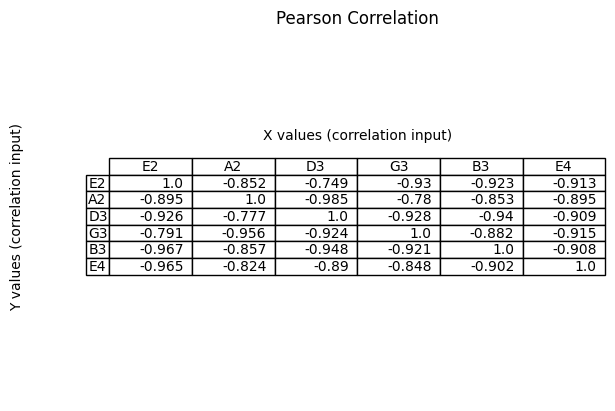

In [12]:
visualize_correlations(example_dataset)

### Durchführung

Die Audio-Dateien sind im Ordner `audio` zu finden.
Die Ordnerstruktur ist wie folgt:

    
    audio/<variable_saite>/<beeinflusste_saite>/<verstimmungsschritt>.wav

    audio
    ├── E2 # Ändernde Saite
      ├── E2 # Beinflusste Saite
        ├─── -4.wav
        ├─── ...
        ├─── 4.wav
      ├─── ...
      ├─── E4
    ├── ...
    ├── E4

#### Setup
Die Gitarre wird per Klinkenkabel an eine Audio-Interface-Karte angeschlossen und mit einer Abtastrate von 44,1 kHz aufgenommen. Die Abbildung zeigt die Positionierung der Gitarre, die so gewählt wurde, dass sich der Hals nicht verzieht und dadurch den Ton beeinflusst. Die Gitarre wird am Stimmwirbel verstimmt, nicht am Feinstimmer an der Brücke.

<div style="border: 1px solid #ccc; padding:1px;"> <img src="assets/setup.jpg" width="500"/> <figcaption>Fig. 12 – Setup der Aufnahme</figcaption> </div>

Die Aufnahmen erfolgen mit der Digital Audio Workstation (DAW) Cubase. Dabei wird in Mono, mit 16 Bit und 44,1 kHz aufgenommen. Zusätzlich wird das in Cubase integrierte Stimmgerät genutzt, um die Frequenz jeder Saite vor jedem Durchgang erneut exakt in die Ausgangsposition zu bringen.

<div style="border: 1px solid #ccc; padding:1px;"> <img src="assets/digital_setup.png" width="500"/> <figcaption>Fig. 13 – Screenshot von Cubase mit Stimmgerät und integriertem Frequenzmessgerät</figcaption> </div>

Jeder Aufnahmeblock enthält die Roh-Audiodaten aller Saiten der Gitarre (E2, A2, D3, G3, B3 und E4). Die Saiten werden in dieser Reihenfolge gespielt. Die Färbung der Blöcke in der DAW visualisiert die Stärke und Richtung der Verstimmung:

* Rottöne → Verstimmung zu tieferen Frequenzen,
* Blautöne → Verstimmung zu höheren Frequenzen.

Jede Zeile in der Aufnahme entspricht einer Saite und einer Verstimmungsrichtung. Von oben nach unten ergibt sich die Reihenfolge:
E2 nach oben, E2 nach unten, A2 nach oben, A2 nach unten, …, E4 nach oben, E4 nach unten.

Im Anschluss werden die einzelnen Audioblöcke so zugeschnitten, dass Transienten und das Ausklingen der Saite entfernt werden. Transienten sind kurze, perkussive Geräusche mit hohem Pegel, die beim Anschlag entstehen und die Frequenzanalyse verfälschen würden.

<div style="border: 1px solid #ccc; padding:1px;"> <img src="assets/cutted_audio.png" width="500"/> <figcaption>Fig. 14 – Screenshot von Cubase mit zugeschnittenen Samples</figcaption> </div>

Jeder zugeschnittene Block wird einzeln exportiert und in den entsprechenden Ordner der oben beschriebenen Struktur verschoben.

### Clean Up
Da von dem oben geschriebenen Python-Programm in manchen Aufnahmen die Obertöne der Saite fälschlicherweise als Ton erkannt wurden, werden die Samples noch einmal gefiltert.
Die folgende Abbildung zeigt eine Konsolenausgabe von dem Problem.

<div style="border: 1px solid #ccc; padding: 1px;">
    <img src="assets/need_to_clean_data.png" width="900"/>
    <figcaption>Fig. 15 – Screenshot der Zeigt das Obertöne erkannt werden statt Grundfrequenzen.</figcaption>
</div>

Der Screenshot zeigt, dass nicht die Grundfrequenz als solche erkannt wird, sondern teilweise Obertöne als Grundfrequenz erkannt werden. \

Die automatische Auswahl des Peaks anhand einer erwarteten Frequenz ist problematisch, da die Grundfrequenz einer Saite variieren kann (z. B. durch Verstimmen oder unterschiedliche Gitarrenstimmungen). Wird die Saite stark von einem Referenzwert abweichen, besteht die Gefahr, dass der falsche Peak erkannt wird. Eine explizite Übergabe der erwarteten Frequenz für jedes Sample wäre möglich, jedoch aufwendig und nicht praktikabel für die allgemeine Analyse. Deshalb wird für jede Saite ein Bandpassfilter erstellt, der die Obertöne reduziert. 

Die folgenden Abbildungen dienten ursprünglich lediglich der Veranschaulichung der Filter und nicht der Spektren des Klanges; ein eventuelles Fehlen der Spektren beeinträchtigt daher die Aussagekraft der Darstellung nicht.

#### Banpass Filter:
<div  style="
    display: flex;
    gap: 12px;
  "
>
  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_e2.png" style="width:500px;">
    <figcaption>Fig. 16 – Bandpass für E2</figcaption>
  </figure>

  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_a2.png" style="width:500px;">
    <figcaption>Fig. 17 – Bandpass für A2</figcaption>
  </figure>
</div>
<div  style="
    display: flex;
    gap: 12px;
  "
>
  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_d3.png" style="width:500px;">
    <figcaption>Fig. 18 – Bandpass für D3</figcaption>
  </figure>

  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_g3.png" style="width:500px;">
    <figcaption>Fig. 19 – Bandpass für G3</figcaption>
  </figure>
</div><div  style="
    display: flex;
    gap: 12px;
  "
>
  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_b3.png" style="width:500px;">
    <figcaption>Fig. 20 – Bandpass für B3</figcaption>
  </figure>

  <figure style="border: 1px solid #ccc; padding: 1px; margin: 0;">
    <img src="assets/bandpass_e4.png" style="width:500px;">
    <figcaption>Fig. 21 – Bandpass für E4</figcaption>
  </figure>
</div>

### Laden der Daten
Im folgenden Script werden die gesamten Audio-Samples geladen, um sie zu verarbeiten und zu visualisieren. Es wird das oben spezifizierte Datenformat zum Speichern der Daten genutzt. 

* Dimensionen:
   * 0: `changing_string`
   * 1: `impacted string`
   * 2: Verstimmungsschritt
* Eintrag = `frequency`.

In [13]:
# Experiment
measured_data = {}
filenames = [f"{i}.wav" for i in step_range]
counter = 0
for changing_string in strings:
    for impacted_string in strings:
        #f0 = get_frequency_from_file(f"audio/{changing_string}/{impacted_string}/0.wav")

        for filename in filenames:
            frequency = get_frequency_from_file(f"audio/{changing_string}/{impacted_string}/{filename}")

            print(
                f"Saite: {changing_string}, Beeinflusste Saite: {impacted_string}, Verstimmungsschritt: {filename}, Frequenz: {frequency}")
            counter+=1
            if changing_string not in measured_data:
                measured_data[changing_string] = {}

            if impacted_string not in measured_data[changing_string]:
                measured_data[changing_string][impacted_string] = []

            measured_data[changing_string][impacted_string].append(frequency)
counter

C:\Users\guita\AppData\Local\Temp\ipykernel_26988\567027934.py:2: WavFileWarning: Chunk (non-data) not understood, skipping it.
  fs, data = wavfile.read(filepath)  # Load the data


Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: -4.wav, Frequenz: 57.56155443488579
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: -3.wav, Frequenz: 67.89055643973762
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: -2.wav, Frequenz: 74.80436177036562
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: -1.wav, Frequenz: 78.13278008298755
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: 0.wav, Frequenz: 82.29854689564068
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: 1.wav, Frequenz: 84.9931433230792
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: 2.wav, Frequenz: 87.45281541913823
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: 3.wav, Frequenz: 92.93188805334641
Saite: E2, Beeinflusste Saite: E2, Verstimmungsschritt: 4.wav, Frequenz: 97.02425718679493
Saite: E2, Beeinflusste Saite: A2, Verstimmungsschritt: -4.wav, Frequenz: 114.39652438637661
Saite: E2, Beeinflusste Saite: A2, Verstimmungsschritt: -3.wav, Frequenz: 112.8823800

324

### Aggregierung der Daten
Gemessen wurden die tatsächlichen Frequenzen jeder Saite und wie sie sich in Abhängigkeit der Veränderung jeder anderen Saite ändern. Für unsere Analyse interessiert uns jedoch vor allem das Maß dieser Änderung. Daher werden alle Messwerte mit ihren jeweiligen Ausgangswerten verglichen – sowohl in Cent als auch in Hertz – um die Frequenzänderungen anschaulich darzustellen.

In [14]:
hz_changes = {  # Dummy Data
    string: {other_string: np.array([float(0) for _ in step_range]) for other_string in strings}
    for string in strings
}
cent_changes = hz_changes.copy()

for changing_string in strings:
    for impacted_string in strings:
        inital_value = measured_data[changing_string][impacted_string][steps]
        for i in range(steps * 2 + 1):  # -4 bis 4
            cent_changes[changing_string][impacted_string][i] = frequency_difference_to_cent(
                measured_data[changing_string][impacted_string][i], inital_value)
            hz_changes[changing_string][impacted_string][i] = measured_data[changing_string][impacted_string][i] - inital_value


## Visualisierung
### Frequenz in Abhängigkeit der Frequenz der Verstimmten Saite (Absolute Werte)

In [15]:
visualize_all(measured_data, label="Hz")

### Frequenz Änderung in Cent (Relative Werte)

In [16]:
visualize_all(cent_changes, label="Cent")

### Frequenz Änderung in Hz (Relative Werte)

In [17]:
visualize_all(hz_changes, label="relative Hz")

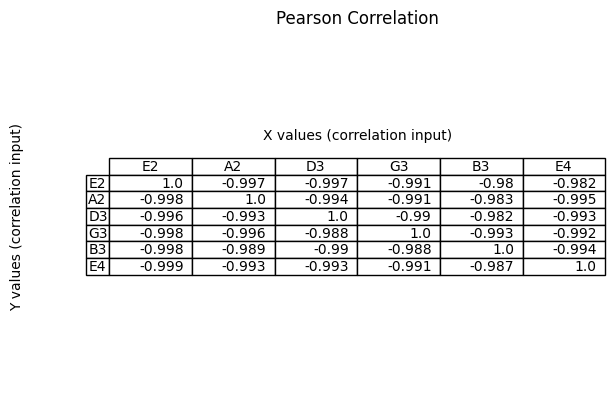

In [18]:
visualize_correlations(hz_changes)

## Diskussion

### Elastizität und Linearität

Das System ist **elastisch**, da Ausgangs- und Endfrequenzen nach jedem Durchgang gleich sind. Während der Durchführung des Experiments fiel auf, dass beim Zurückbringen einer Saite in ihre Ausgangsposition alle anderen Saiten ebenfalls wieder ihre ursprüngliche Frequenz annahmen.  

Die Linearität des Systems ist nicht perfekt, aber hinreichend gut für kleine Verstimmungen. Sie lässt sich quantitativ mit dem **Korrelationskoeffizienten nach Bravais-Pearson** zwischen gemessenen und erwarteten Frequenzänderungen jeder Saite bestimmen. Eine hohe Korrelation bestätigt, dass die Annahme einer linearen Beziehung für kleine Änderungen gerechtfertigt ist.  

Die Linearität ist wichtig, da sie die Grundlage für die Modellierung als **lineares Gleichungssystem** bildet. Nur dadurch können die Effekte der Verstimmung jeder Saite auf alle anderen Saiten mit einer **Matrix** erfasst und mathematisch gelöst werden.

### Mathematische Modellierung der Verstimmungen

Die Frequenzen der Saiten können als **Vektor** dargestellt werden:

$$
\vec{f_0} = \begin{pmatrix} {f_{\text{E2}}} \\ {f_{\text{A2}}} \\ {f_{\text{D3}}} \\ {f_{\text{G3}}} \\ {f_{\text{B3}}} \\ {f_{\text{E4}}} \end{pmatrix},
C = \begin{bmatrix} 
1 & c_{12} & c_{13} & c_{14} & c_{15} & c_{16} \\ 
c_{21} & 1 & c_{23} & c_{24} & c_{25} & c_{26} \\ 
c_{31} & c_{32} & 1 & c_{34} & c_{35} & c_{36} \\ 
c_{41} & c_{42} & c_{43} & 1 & c_{45} & c_{46} \\ 
c_{51} & c_{52} & c_{53} & c_{54} & 1 & c_{56} \\ 
c_{61} & c_{62} & c_{63} & c_{64} & c_{65} & 1 
\end{bmatrix},
\vec{g} = \begin{pmatrix} {\hat{f}_{\text{E2}}} \\ {\hat{f}_{\text{A2}}} \\ {\hat{f}_{\text{D3}}} \\ {\hat{f}_{\text{G3}}} \\ {\hat{f}_{\text{B3}}} \\ {\hat{f}_{\text{E4}}} \end{pmatrix}
$$

- $\vec{f_0}$: Ausgangsfrequenzen der Saiten, gemessen z. B. mit einem digitalen Stimmgerät  
- $C$: Verstimmungsmatrix, wobei $c_{ij}$ den **Verstimmungsfaktor** der Saite $i$ angibt, wenn die Saite $j$ um 1 Hz verstimmt wird  
- $\vec{g}$: Ziel-Frequenzen nach der Verstimmung  

Der Vektor  

$$
\vec{\Delta} = \begin{pmatrix} {\Delta_{\text{E2}}} \\ {\Delta_{\text{A2}}} \\ {\Delta_{\text{D3}}} \\ {\Delta_{\text{G3}}} \\ {\Delta_{\text{B3}}} \\ {\Delta_{\text{E4}}} \end{pmatrix}
$$ 

gibt an, um wie viel jede Saite verstimmt werden muss. 

Die **effektive Verstimmung** wird durch die Multiplikation mit der Verstimmungsmatrix berechnet:  

$$
 C \cdot  \vec{\Delta}  = \vec{\Delta}_{\text{effective}}
$$

Damit die Ziel-Frequenzen $\vec{g}$ erreicht werden, gilt:  

$$
\vec{g} = \vec{f_0} +  \vec{\Delta}_{\text{effective}} \quad \Rightarrow \quad \vec{\Delta}_{\text{effective}}  = \vec{g}-\vec{f_0}
$$

Um die Eingangsverstimmung $\vec{\Delta}$ zu bestimmen, muss das **Inverse der Matrix $C$** gebildet werden:  

$$
 C \cdot \vec{\Delta}   = \vec{\Delta}_{\text{effective}}  \quad \Rightarrow \quad \vec{\Delta} = C^{-1} \cdot \vec{\Delta}_{\text{effective}} 
$$

$$
\vec{\Delta} = C^{-1} \cdot (\vec{g}-\vec{f_0})  
$$

$C^{-1}$ ist die Inverse der Verstimmungsmatrix.

Somit benötigt man für die Berechnung:  
1. Ausgangsfrequenzen $\vec{f_0}$  
2. Ziel-Frequenzen $\vec{g}$  
3. Verstimmungsmatrix $C$

### Programmierung

Die Berechnung wird in **Python** mit `numpy` umgesetzt, da die Bibliothek einfache Funktionen für **Matrix-Multiplikation** und **Matrixinversion** bietet.  

Die zu implementierende Funktion lautet:

$$
\vec{\Delta} = C^{-1} \cdot (\vec{g}-\vec{f_0})  
$$

Am Ende liefert sie einen Vektor, der für jede Saite angibt, um wie viel Hertz diese verstimmt werden muss.

python:
```py
np.linalg.inv(C) @ (g - f0)  
```

Die Ziel Frequenzen $\vec{g}$ sind Konstant und sind für eine moderne westliche Stimmung [6]
$$
\vec{g} = \begin{pmatrix} { 82.41 Hz} \\ {110.00 Hz} \\ {146.83 Hz} \\ {196.00 Hz} \\ {246.94 Hz} \\ {329.63 Hz} \end{pmatrix}
$$

In [19]:
g = np.array([ 82.41, 
              110.00,
              146.83,
              196.00,
              246.94,
              329.63])

Die Koeffizienten/Verstimmungsmatrix müsste zunächst gemessen werden. Aus dem Experiment können die Koeffizienten abgeleitet werden.

In [20]:
def orthogonal_regression(x, y):
    # implementation retrieved from https://de.wikipedia.org/wiki/Orthogonale_Regression
    assert x.shape == y.shape and x.size > 1

    mean_x, mean_y = x.mean(), y.mean()
    var_x, var_y = x.var(ddof=1), y.var(ddof=1)
    cov_xy = np.cov(x, y, ddof=1)[0, 1]

    if np.isclose(cov_xy, 0):
        return 0.0, mean_y

    slope = (var_y - var_x + np.sqrt((var_y - var_x)**2 + 4 * cov_xy**2)) / (2 * cov_xy)
    intercept = mean_y - slope * mean_x

    return slope, intercept

def get_factor(x, y):
    return orthogonal_regression(x,y)[0]
    
    

In [21]:
# Koeffizienten Matrix Füllen
C = np.zeros(shape=(6,6)) # init Matrix
j = 0 # zähler für den index in C 
for changing_string in strings: # j ist hier die sich ändernde Saite 
    compare = hz_changes[changing_string][changing_string]
    i = 0
    for influenced_string in strings:
        C[i,j] = get_factor(compare,hz_changes[changing_string][influenced_string])
        i += 1
    j += 1

In [22]:


def _luminance_from_value(val: float, cmap, norm) -> float:
    """Perceived brightness aus dem Colormap-Mapping."""
    rgba = cmap(norm(val))
    return 0.299 * rgba[0] + 0.587 * rgba[1] + 0.114 * rgba[2]


def choose_text_color(val: float, cmap, norm, lum_threshold=0.5) -> str:
    """Adaptive Schriftfarbe (weiß auf dunkel, schwarz auf hell)."""
    lum = _luminance_from_value(val, cmap, norm)
    return 'white' if lum < lum_threshold else 'black'


def annotate_cells(ax, C: np.ndarray, im, diag_value=1.0, fmt="{:.2f}", fontsize=9):
    """Schreibt Werte in jede Zelle; Diagonale wird als konstanter Wert dargestellt."""
    n = C.shape[0]
    cmap, norm = im.cmap, im.norm

    for i in range(n):
        for j in range(n):
            if i == j:
                val = diag_value
                color = 'black'  # neutral
            else:
                val = C[i, j]
                color = choose_text_color(val, cmap, norm)

            ax.text(j, i, fmt.format(val),
                    ha='center', va='center',
                    color=color, fontsize=fontsize)

def plot_detuning_matrix(C: np.ndarray, *,
                            cmap='viridis',
                            title='Verstimmungsmatrix C',
                            cbar_label='Verstimmungsfaktor',
                            diag_value=1.0,
                            figsize=(6, 5),
                            save_path="assets/detuning_matrix_example.png"):

    # --- Basic sanity check (optional, aber sinnvoll) ---
    assert C.shape[0] == C.shape[1], "C muss quadratisch sein"
    assert C.shape[0] == len(strings), "strings muss zur Matrix passen"

    # --- Diagonale aus Darstellung entfernen ---
    M = C.astype(float).copy()
    np.fill_diagonal(M, np.nan)

    fig, ax = plt.subplots(figsize=figsize)

    im = ax.imshow(M, cmap=cmap, interpolation='nearest')

    # FIX: falscher Variablenname
    fig.colorbar(im, ax=ax, label=cbar_label)

    # FIX: Einrückung
    n = len(strings)
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(strings)
    ax.set_yticklabels(strings)
    ax.set_xlabel("Changing String")
    ax.set_ylabel("Impact on String")
    
    ax.set_title(title)

    # Zahlen reinmalen
    annotate_cells(ax, C, im, diag_value=diag_value)

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

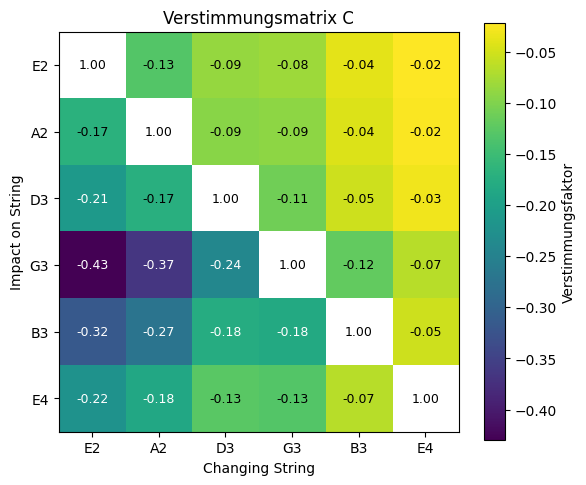

In [23]:
plot_detuning_matrix(C)

Um zu überprüfen, ob die Matrix korrekt transponiert wurde, können wir die Graphen heranziehen. Dabei haben wir festgestellt, dass die G-Saite am empfindlichsten auf Änderungen der anderen Saiten reagiert. In der Matrix gilt: die Spalten stehen für die verstimmte (verursachende) Saite, die Zeilen für die davon betroffene Saite. Da die G-Saite besonders stark von allen anderen beeinflusst wird, sollte sich dies in der vierten Zeile (G-Saite) durch deutlich negative Werte zeigen. Anschließend muss nur noch die aktuelle Stimmung mit einem Frequenzmessgerät erfasst werden, und wir verfügen über alle nötigen Parameter, um den Algorithmus anzuwenden.

In [24]:
aktuelle_stimmung = np.array([ 
              80, 
              113.00,
              142.2,
              200.00,
              242.4,
              319.33])
"""
Sollte am Ende sein: 
              82.41, 
              110.00,
              146.83,
              196.00,
              246.94,
              329.63
"""
d = np.linalg.inv(C) @ (g - aktuelle_stimmung)
d

array([ 3.26380937, -1.32730945,  5.8005198 , -0.05672601,  6.86460835,
       11.96085739])

In [25]:
# Test
np.allclose((C @ d) + aktuelle_stimmung, g)


True

# Anwendung für Gitarrist:innen

Um diese Erkenntnisse praktisch nutzbar zu machen, könnte man eine App entwickeln, die Gitarrist:innen bei folgenden Schritten unterstützt:

1. **Einmalige Bestimmung der Koeffizientenmatrix C**  
   Die App enthält ein integriertes Stimmgerät und gibt Anweisungen, die Gitarrensaiten nacheinander auf verschiedene Frequenzen zu stimmen. Anschließend wird gemessen, wie sich diese Änderungen auf die übrigen Saiten auswirken. Auf diese Weise lässt sich für jede Gitarre die individuelle Koeffizientenmatrix C bestimmen.

2. **Messung des aktuellen Zustands**  
   Mit dem integrierten Frequenzmessgerät kann die momentane Stimmung der Gitarre erfasst werden. Dazu schlägt die Nutzer:in jede Saite einzeln an, sodass die App die Ist-Frequenzen registriert.

3. **Stimmvorgang**  
   Die App zeigt für jede Saite sowohl die gemessene Ist-Frequenz als auch die berechnete Soll-Frequenz an. Die Soll-Frequenzen werden mit Hilfe des entwickelten Algorithmus bestimmt. Nach dem Stimmen wird eine erneute Messung durchgeführt, um zu überprüfen, ob die gesamte Gitarre korrekt gestimmt ist.


# Ausblick

Die nächsten Schritte bestehen darin, eine App zu entwickeln, die Gitarrist:innen beim Stimmen einer Floyd-Rose-Gitarre tatsächlich unterstützt.  

Darüber hinaus ist es interessant zu untersuchen, warum manche Saiten stärker durch die Verstimmung anderer Saiten beeinflusst werden. Eine mögliche Theorie lautet, dass bestimmte Saiten weiter außen auf dem sich drehenden Tremolo liegen und dadurch bei einer Bewegung einen größeren Weg zurücklegen. Bei der hier verwendeten Gitarre befindet sich die G-Saite tatsächlich auf der am weitesten entfernten Umlaufbahn. Diese Annahme ließe sich durch weitere Experimente überprüfen und gegebenenfalls bestätigen.


## Literatur

[1] Young's Modulus: https://en.wikipedia.org/wiki/Young%27s_modulus \
[2] Hookesches Gesetz: https://de.wikipedia.org/wiki/Hookesches_Gesetz \
[3] Mersennsche Gesetz: https://en.wikipedia.org/wiki/Mersenne%27s_laws \
[4] Vibration of a String: https://en.wikipedia.org/wiki/String_vibration \
[5] Mechanische Spannung: https://de.wikipedia.org/wiki/Mechanische_Spannung \
[6] Stimmung einer Gitarre: https://de.wikipedia.org/wiki/Stimmen_einer_Gitarre \
[7] Gleich temperierte Stimmung: https://de.wikipedia.org/wiki/Gleichstufige_Stimmung \
[8] Cent: https://de.wikipedia.org/wiki/Cent_(Musik) 

## Abbildungen
Fig. 1: https://blog.teufel.de/wp-content/uploads/2024/06/fender-gitarre-aufbau-begriffe.jpg \
Fig. 2: https://www.gearnews.de/workshop-tremolo-einstellen-so-klappts/ \
Alle anderen Abbildung: Raphael Schütz, raphael.schuetz0311@gmail.com 